In [1]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error, accuracy_score, recall_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
df = pd.read_csv('manufacturing.csv')
df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


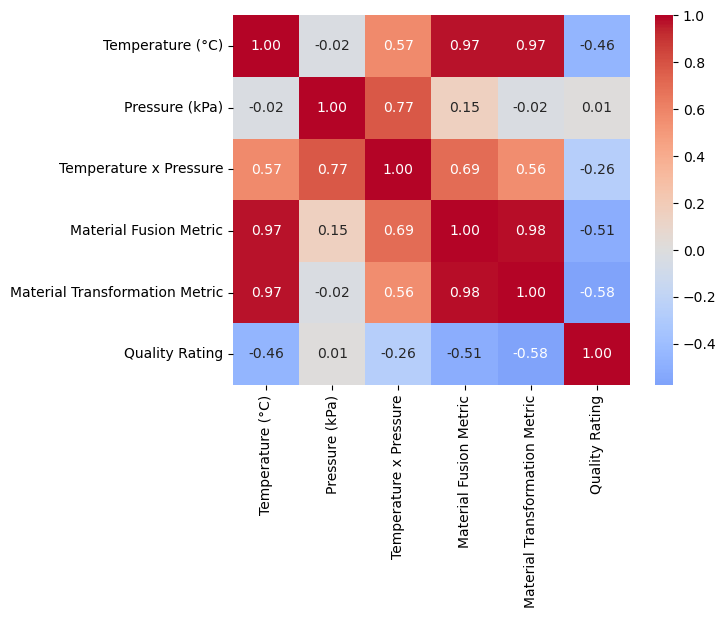

In [2]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.show()

In [3]:
X = df.iloc[:,0:5]
y = df['Quality Rating']

In [4]:
X = StandardScaler().fit_transform(X)

In [5]:
pd.DataFrame(X).head()

,0,1,2,3,4
0,0.167354,-1.172126,-0.868667,-0.151411,-0.106191
1,0.739797,0.172666,0.608769,0.625539,0.568398
2,0.352977,-1.208119,-0.840510,0.041949,0.091063
3,0.153831,1.554332,1.382277,0.378076,-0.119861
4,-0.263275,0.170196,-0.025360,-0.422483,-0.491243


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

0.9999999999999986


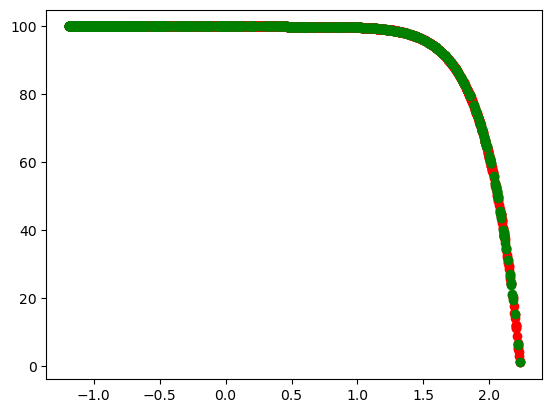

In [7]:
steps = [
    ('poly', PolynomialFeatures(degree = 10)),
    ('model', LinearRegression())
]
pipe = Pipeline(steps)
param_grid = {
    'poly__degree' : [4,5,7,10]
}
#pipe.fit(X_train, y_train)
gscv = GridSearchCV(estimator = pipe, param_grid = param_grid)
gscv.fit(X_train, y_train)
model = gscv.best_estimator_
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))

plt.scatter(X_train[:,4], y_train, c = 'red')
plt.scatter(X_test[:,4], y_pred, c = 'green')
plt.show()

In [8]:
print(gscv.best_params_)

{'poly__degree': 10}
